# More limitations of `numpy` arrays, and how to overcome them

In this demo, we will continue to explore limits of `numpy` arrays. Our example dataset will be a large 3D image of a whole bird brain, courtesy of [Simon Weiler.](https://simonweiler.github.io/)

On the biological side, this is a whole brain image of a Eurasian blackcap, a migratory bird species. It was made using serial-section two-photon tomography.


On the technical side, it takes the form of a folder containing almost 2100 TIFF files of 43 MB each, totalling over 90 GB. Each tiff file is a coronal slice. This setup means that we can easily load any single slice into memory, but never the entire three-dimensional array at the same time.

We start our journey by importing a helper function that allows us to monitor the memory and execution time of each cell in the notebook.

To monitor time and memory, we need to add `%%monitor` at the top of the cell.

In [2]:
%%monitor

print("hello, I am being monitored")

'starting...'

hello, I am being monitored

--- Monitoring report ---
[memory] current: 0.4 MB, peak: 1.1 MB
[speed] time elapsed: 0.021s


Unsurprisingly, printing a message is very fast and uses minimal memory. We can explore the files containing the bird brain image on disk with Python with `os.listdir` and print the first ten.

In [3]:
%%monitor

from os import listdir
from pathlib import Path
import numpy as np
import tifffile

path = Path("/home/alessandro/data/blackcap-highres")

list_of_tiffs = [path / name for name in listdir(path) if name.endswith("tif")]

_ = [print(str(tiffpath)) for tiffpath in list_of_tiffs[:10]]

'starting...'

/home/alessandro/data/blackcap-highres/section_071_04.tif
/home/alessandro/data/blackcap-highres/section_037_08.tif
/home/alessandro/data/blackcap-highres/section_098_01.tif
/home/alessandro/data/blackcap-highres/section_023_05.tif
/home/alessandro/data/blackcap-highres/section_024_07.tif
/home/alessandro/data/blackcap-highres/section_088_03.tif
/home/alessandro/data/blackcap-highres/section_158_09.tif
/home/alessandro/data/blackcap-highres/section_039_03.tif
/home/alessandro/data/blackcap-highres/section_102_02.tif
/home/alessandro/data/blackcap-highres/section_034_08.tif

--- Monitoring report ---
[memory] current: 2.7 MB, peak: 3.3 MB
[speed] time elapsed: 0.054s


If we only care about visualing a coronal slice, this is easy. We can load for example the 1000th slice into a numpy array using the `tifffile` library. Our monitoring code confirms that we roughly 40 MB of memory, as expected.

In [4]:
%%monitor

print(f"We have {len(list_of_tiffs)} files")
coronal_slice = tifffile.imread(list_of_tiffs[1000])
print(f"Each file has shape {coronal_slice.shape}")

stack_shape = (len(list_of_tiffs), *coronal_slice.shape)
stack_dtype = coronal_slice.dtype
print(f"The 3D image has shape {stack_shape} and has datatype {stack_dtype}.")

'starting...'

We have 2090 files
Each file has shape (3922, 5521)
The 3D image has shape (2090, 3922, 5521) and has datatype uint16.

--- Monitoring report ---
[memory] current: 43.4 MB, peak: 43.4 MB
[speed] time elapsed: 0.014s


And we can plot its contents

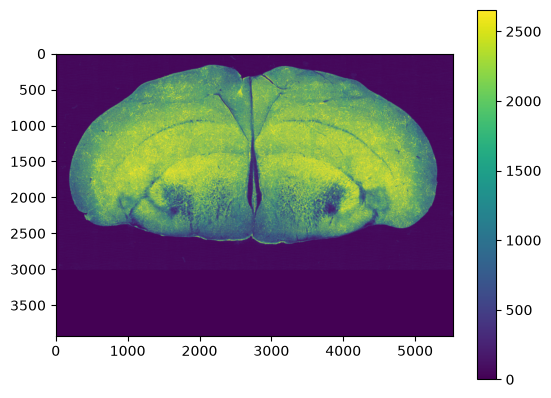

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(coronal_slice, vmax=np.percentile(coronal_slice, 90))
plt.colorbar()
plt.show()

We hit our limits if we want to read a few hundred slices into a three-dimensional numpy array in memory, because this is 10-20 GB. This stops us from visualising a sagittal slice, because that would require us to load _all_ coronal slices into memory (even though we need just a small bit of each coronal slice).

In [6]:
%%monitor

number_of_images = 300

stack = np.empty(
    (number_of_images, stack_shape[1], stack_shape[2]), dtype=stack_dtype
)

for i, tiff_path in enumerate(list_of_tiffs[:number_of_images]):
    stack[i] = tifffile.imread(tiff_path)


'[t=  8.52s] current=13035.9MB peak=13036.5MB'


--- Monitoring report ---
[memory] current: 12992.6 MB, peak: 13036.5 MB
[speed] time elapsed: 8.624s


We can solve this problem with a "memory map". A memory map allows us to tell `numpy` that not to allocate memory eagerly, by reassuring it that it will able to load the data from disk whenever we actually ask for it. This allows us to create a sagittal slice!

In [7]:
%%monitor

sagittal_slice = np.empty(
    (stack_shape[0], stack_shape[1]), dtype=stack_dtype
)

for i, tiff_path in enumerate(sorted(list_of_tiffs)):
    sagittal_slice[i] = tifffile.memmap(tiff_path)[:, 2000]

'[t= 93.44s] current=18.2MB peak=18.7MB'


--- Monitoring report ---
[memory] current: 18.2 MB, peak: 18.7 MB
[speed] time elapsed: 93.610s


'[t=  0.51s] current=17.2MB peak=402.3MB'

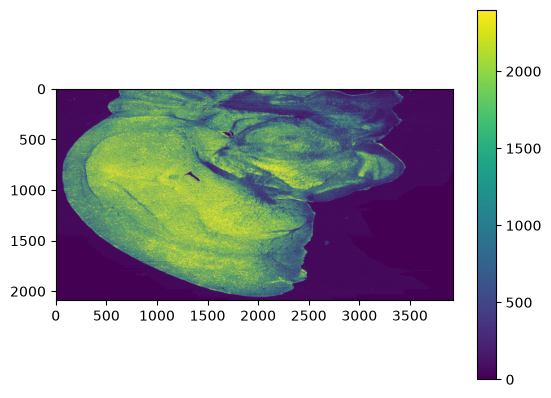


--- Monitoring report ---
[memory] current: 17.8 MB, peak: 402.9 MB
[speed] time elapsed: 0.978s


In [8]:
%%monitor

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(sagittal_slice, vmax=np.percentile(sagittal_slice, 90))
plt.colorbar()
plt.show()

This is very memory efficient, so memory maps are a great solution, if the data is on your local disk and you are willing to do some coding acrobatics. 

## Joint exercise

Next, we can do a small exercise, which is a variation of the above plotting of a sagittal section: plot a transverse section.

In [9]:
%%monitor

# Exercise code here: you might want to copy paste the sagittal section plotting code above

'starting...'


--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.0 MB
[speed] time elapsed: 0.002s


Memory maps has some disadvantages when

* your data doesn't live on disk (e.g. on the cloud)
* you need to process your data in parallel
* your data is compressed, or you want to compress it
* you want to keep track of your metadata
* you want to slice the same array in different ways, or the order in the memory map doesn't match your access pattern

`dask` and `zarr` libraries provide functionality to overcome these disadvantages.

Next, we will combine `memmap` and `dask` to make an entirely lazy 3D stack, that we can efficiently slice however we want.

In [10]:
%%monitor

import dask.array as da
from dask import delayed

dask_stack = da.stack([
    da.from_delayed(delayed(tifffile.memmap)(tiffpath), shape=(stack_shape[1], stack_shape[2]), dtype=stack_dtype)
    for tiffpath in sorted(list_of_tiffs)
])

print(dask_stack.shape)
coronal_slice = dask_stack[1000, :, :]
sagittal_slice = dask_stack[:, 2000, :]
horizontal_slice = dask_stack[:, :, 3000]

'[t=  1.62s] current=20.1MB peak=20.1MB'

(2090, 3922, 5521)

--- Monitoring report ---
[memory] current: 22.7 MB, peak: 22.9 MB
[speed] time elapsed: 1.827s


The `dask` stack is entirely lazy, and delays execution to when we actually need it (for example, when we plot the data).

'[t= 28.91s] current=461.4MB peak=1109.7MB'

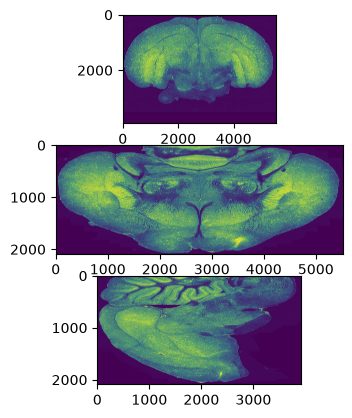


--- Monitoring report ---
[memory] current: 92.1 MB, peak: 1109.7 MB
[speed] time elapsed: 29.295s


In [11]:
%%monitor

plt.figure()
plt.subplot(3,1,1)
plt.imshow(coronal_slice, vmax=3000)
plt.subplot(3,1,2)
plt.imshow(sagittal_slice, vmax=3000)
plt.subplot(3,1,3)
plt.imshow(horizontal_slice, vmax=3000)
plt.show()

## Key take-aways

* We have seen various ways of slicing a 91 GB array without ever using more than 1 GB of memory, which is pretty impressive!
* `memmap` techniques allow you to load data in `numpy` arrays lazily, but have some limitations
* `dask` provides more flexibility the `memmap`, allowing arbitrary slicing
   * future exercises showcase how `dask` and `zarr` overcome other `memmap` limitations too. 